# TP, TN, FP, FN, and Confusion Matrix

In the previous lecture note, we trained a logistic regression model to predict whether a tumor is:

- `0 = benign`
- `1 = malignant`

We also used the **test set** to compare the true labels and predicted labels.

In this lecture note, we focus on one question:

**What kinds of correct and wrong predictions did our model make?**

To answer that, we will learn:

- true positive (TP)
- true negative (TN)
- false positive (FP)
- false negative (FN)
- confusion matrix

In a later lecture note, we will use these ideas to study performance metrics such as **accuracy, recall, precision, and F1 score**.

## Review of the Test-Set Results

We continue with the same tumor example from the previous lecture note.

In this revised notebook, the dataset size is increased by **100%**.
So the dataset now has **60 observations instead of 30**.

The logistic regression model is trained on **45 training cases** and tested on **15 test cases**.

With this updated dataset and split, the model makes **both** false positives and false negatives, and both counts are **greater than 1**.

That makes this version more useful for teaching the confusion matrix.


In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

tumor_size = np.array([
    1.0, 1.2, 1.5, 1.8, 2.0, 2.1, 2.3, 2.5, 2.7, 2.8,
    3.0, 3.1, 3.3, 3.5, 3.6, 3.8, 4.0, 4.2, 4.5, 4.8,
    5.0, 5.2, 5.5, 5.8, 6.0, 6.2, 6.5, 6.8, 7.0, 7.5
])

diagnosis = np.array([
    0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
    0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
    1, 1, 0, 1, 1, 1, 1, 1, 1, 1
])

# Increase the dataset size by 100%
tumor_size_extra = tumor_size + 0.05
diagnosis_extra = diagnosis.copy()

tumor_size = np.concatenate([tumor_size, tumor_size_extra])
diagnosis = np.concatenate([diagnosis, diagnosis_extra])

X = tumor_size.reshape(-1, 1)
y = diagnosis

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=25
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## Training Data Points and the Sigmoid Curve

Before we focus on the confusion matrix, it is helpful to look at the **training data** and the **sigmoid curve** learned by logistic regression.

- Each dot below is one **training data point**
- `0` means **benign**
- `1` means **malignant**
- The smooth S-shaped curve is the **sigmoid curve**
- The curve shows the model's predicted probability that a tumor is malignant

This diagram helps connect the earlier logistic regression lecture note to the confusion matrix lecture note.


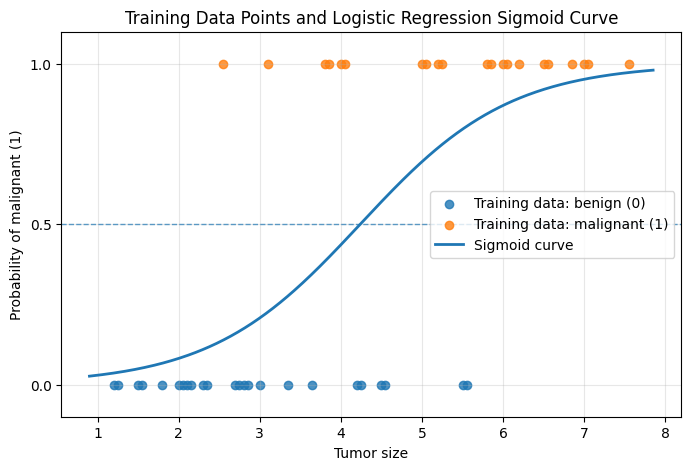

In [2]:
import matplotlib.pyplot as plt

x_plot = np.linspace(X_train.min() - 0.3, X_train.max() + 0.3, 400).reshape(-1, 1)
y_prob = model.predict_proba(x_plot)[:, 1]

plt.figure(figsize=(8, 5))
plt.scatter(X_train[y_train == 0], y_train[y_train == 0], label="Training data: benign (0)", alpha=0.8)
plt.scatter(X_train[y_train == 1], y_train[y_train == 1], label="Training data: malignant (1)", alpha=0.8)
plt.plot(x_plot, y_prob, linewidth=2, label="Sigmoid curve")
plt.axhline(0.5, linestyle="--", linewidth=1, alpha=0.7)
plt.xlabel("Tumor size")
plt.ylabel("Probability of malignant (1)")
plt.title("Training Data Points and Logistic Regression Sigmoid Curve")
plt.yticks([0, 0.5, 1.0])
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [3]:
print("Tumor sizes in test set:", X_test.ravel())
print("True labels:           ", y_test)
print("Predicted labels:      ", y_pred)

Tumor sizes in test set: [4.8  3.3  3.5  7.5  2.5  3.15 6.8  1.05 3.05 6.25 3.55 1.   4.85 3.6
 1.85]
True labels:            [0 0 1 1 1 1 1 0 0 1 1 0 0 0 0]
Predicted labels:       [1 0 0 1 0 0 1 0 0 1 0 0 1 0 0]


## Positive Class and Negative Class

In this lecture note:

- **Positive class** = malignant = `1`
- **Negative class** = benign = `0`

This is important because TP, TN, FP, and FN depend on which class is considered the **positive class**.

## Step 1: Compare the True Labels and Predicted Labels

Using the updated doubled dataset, the **test set contains 15 cases**.

| Test case | Tumor size | True label | Predicted label |
|---|---:|---:|---:|
| 1 | 4.8 | 0 | 1 |
| 2 | 3.3 | 0 | 0 |
| 3 | 3.5 | 1 | 0 |
| 4 | 7.5 | 1 | 1 |
| 5 | 2.5 | 1 | 0 |
| 6 | 3.15 | 1 | 0 |
| 7 | 6.8 | 1 | 1 |
| 8 | 1.05 | 0 | 0 |
| 9 | 3.05 | 0 | 0 |
| 10 | 6.25 | 1 | 1 |
| 11 | 3.55 | 1 | 0 |
| 12 | 1 | 0 | 0 |
| 13 | 4.85 | 0 | 1 |
| 14 | 3.6 | 0 | 0 |
| 15 | 1.85 | 0 | 0 |

Now we classify each result as TP, TN, FP, or FN.


## Step 2: What Do TP, TN, FP, and FN Mean?

### True Positive (TP)
The true label is `1` and the model predicts `1`.

- actual tumor is malignant
- model predicts malignant

### True Negative (TN)
The true label is `0` and the model predicts `0`.

- actual tumor is benign
- model predicts benign

### False Positive (FP)
The true label is `0` but the model predicts `1`.

- actual tumor is benign
- model incorrectly predicts malignant

### False Negative (FN)
The true label is `1` but the model predicts `0`.

- actual tumor is malignant
- model incorrectly predicts benign

In medicine, a **false negative** can be especially serious because a real cancer is missed.

## Step 3: Label the Test Cases

Using the definitions above:

| Test case | Tumor size | True label | Predicted label | Result |
|---|---:|---:|---:|---|
| 1 | 4.8 | 0 | 1 | FP |
| 2 | 3.3 | 0 | 0 | TN |
| 3 | 3.5 | 1 | 0 | FN |
| 4 | 7.5 | 1 | 1 | TP |
| 5 | 2.5 | 1 | 0 | FN |
| 6 | 3.15 | 1 | 0 | FN |
| 7 | 6.8 | 1 | 1 | TP |
| 8 | 1.05 | 0 | 0 | TN |
| 9 | 3.05 | 0 | 0 | TN |
| 10 | 6.25 | 1 | 1 | TP |
| 11 | 3.55 | 1 | 0 | FN |
| 12 | 1 | 0 | 0 | TN |
| 13 | 4.85 | 0 | 1 | FP |
| 14 | 3.6 | 0 | 0 | TN |
| 15 | 1.85 | 0 | 0 | TN |

So the counts are:

- `TP = 3`
- `TN = 6`
- `FP = 2`
- `FN = 4`


In [4]:
tp = ((y_test == 1) & (y_pred == 1)).sum()
tn = ((y_test == 0) & (y_pred == 0)).sum()
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()

print("TP =", tp)
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)

TP = 3
TN = 6
FP = 2
FN = 4


## Step 4: Build the Confusion Matrix

We will use the following format throughout this lecture note:

|            | Predicted 0 | Predicted 1 |
|------------|-------------|-------------|
| Actual 0   | TN          | FP          |
| Actual 1   | FN          | TP          |

So the **rows** show the **actual labels**, and the **columns** show the **predicted labels**.

Using our updated tumor example:

|            | Predicted 0 | Predicted 1 |
|------------|-------------|-------------|
| Actual 0   | 6           | 2           |
| Actual 1   | 4           | 3           |

So the confusion matrix is:

$$
\begin{bmatrix}
6 & 2 \\
4 & 3
\end{bmatrix}
$$


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[6, 2],
       [4, 3]])

## Interpreting the Confusion Matrix

Our confusion matrix shows:

- `6` true negatives  
  The model correctly predicted benign tumors.

- `3` true positives  
  The model correctly predicted malignant tumors.

- `2` false positives  
  The model incorrectly labeled `2` benign tumors as malignant. These are **false alarms**.

- `4` false negatives  
  The model missed `4` malignant tumors and predicted benign instead.

This updated result is useful for teaching because the model makes **both types of mistakes**, and each type appears more than once.

So students can more clearly see the difference between a **false positive** and a **false negative** in the confusion matrix.


## Why This Matters

TP, TN, FP, and FN are the foundation for many performance metrics.

In a later lecture note, we will use these four numbers to calculate:

- accuracy
- recall
- precision
- F1 score

So the confusion matrix is not the end.

It is the starting point for model evaluation.

## Practice Problems

### Question 1
In this tumor example, which class is the **positive class**?

<details>
<summary>Show answer</summary>

The positive class is **malignant = 1**.

</details>

### Question 2
If the true label is `1` and the predicted label is `0`, what type of prediction is this?

<details>
<summary>Show answer</summary>

This is a **false negative (FN)**.

</details>

### Question 3
Suppose the model predicted **malignant (`1`) for all 15 test cases**. What would `TP`, `TN`, `FP`, and `FN` be?

<details>
<summary>Show answer</summary>

There are `7` actual malignant tumors and `8` actual benign tumors in the test set.

So if the model predicts `1` for all 15 cases:

- `TP = 7`
- `TN = 0`
- `FP = 8`
- `FN = 0`

</details>

### Question 4
In our confusion matrix, what does the entry in the row **Actual 1** and the column **Predicted 0** represent?

<details>
<summary>Show answer</summary>

It represents the number of **false negatives (FN)**.

These are tumors that are actually malignant but were predicted as benign.

</details>

### Question 5
Why can a false negative be especially serious in cancer prediction?

<details>
<summary>Show answer</summary>

A false negative means the tumor is actually malignant, but the model predicts benign.

That means a real cancer is missed.

</details>

### Question 6
What is the main purpose of the confusion matrix?

<details>
<summary>Show answer</summary>

The confusion matrix summarizes the counts of:

- `TP`
- `TN`
- `FP`
- `FN`

It helps us understand **what kinds of correct and wrong predictions** the model made.

</details>


## Summary

In this lecture note, we learned:

- how the **training data points** relate to the **sigmoid curve** in logistic regression
- the difference between **positive** and **negative** classes
- the meanings of **TP, TN, FP, and FN**
- how to identify those cases from true and predicted labels
- how to build and interpret a **confusion matrix**

In a later lecture note, we will use the confusion matrix to calculate:

- accuracy
- recall
- precision
- F1 score
